# K-Moda MMM — Modelo Baseline

**Input:** `data/processed/02_features_mmm.csv` — dataset con features preparados  
**Output:** Modelo Ridge entrenado, coeficientes, métricas MAPE, modelo guardado en `models/`

---

## Objetivo

Entrenar un **modelo de regresión lineal con regularización Ridge** como baseline para el MMM de K-Moda. Este modelo servirá como punto de referencia para evaluar mejoras futuras (ej. modelos bayesianos).

- **Variable objetivo:** `ventas` (o `log_ventas` si se decide)
- **Features:** Adstock saturado por canal, tendencia, estacionalidad, calendario, ciudad
- **Evaluación:** MAPE en train/test, coeficientes por canal

---

## Estructura

1. Librerías y configuración  
2. Carga de datos  
3. Exploración y preprocesamiento  
4. Partición temporal (train / test)  
5. Entrenamiento del modelo Ridge  
6. Evaluación: coeficientes y contribuciones  
7. Métricas: MAPE train/test  
8. Visualizaciones  
9. Guardado del modelo  
10. Conclusiones y próximos pasos

In [1]:
# 1. Librerías y configuración
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Paths
DATA_PATH = '../data/processed/02_features_mmm.csv'
MODEL_PATH = '../models/mmm_ridge_baseline.pkl'
FIGS_PATH = '../reports/figures/'

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
# 2. Carga de datos
df = pd.read_csv(DATA_PATH)
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nPrimeras filas:")
display(df.head())

print("\nInfo del dataset:")
df.info()

Dataset cargado: 1310 filas × 76 columnas

Primeras filas:


,semana_inicio,ciudad,ventas_eur,unidades,margen_eur,inv_display,inv_email_crm,inv_exterior,inv_paid_search,inv_prensa,...,flag_incidencia_ecommerce,temperatura_media_z,lluvia_media_z,turismo_indice_medio_z,ciudad_bilbao,ciudad_madrid,ciudad_sevilla,ciudad_valencia,log_ventas_eur,split
0,2019-12-30,Barcelona,254999.88,6714,155531.15,0.00,0.00,0.00,0.00,0.00,...,0,-0.939307,0.308122,-0.136170,0,0,0,0,12.449018,train
1,2020-01-06,Barcelona,349868.95,9143,213578.48,1748.40,267.81,2797.06,3894.21,2216.74,...,0,-0.905615,0.934823,0.042092,0,0,0,0,12.765314,train
2,2020-01-13,Barcelona,358427.61,9304,218085.71,1274.28,1349.57,1943.18,5033.46,2162.01,...,0,-1.093512,1.038883,-0.160797,0,0,0,0,12.789482,train
3,2020-01-20,Barcelona,357865.71,9318,217766.90,2389.12,1063.84,2483.64,4783.12,810.75,...,0,-1.123749,0.867927,-0.262941,0,0,0,0,12.787913,train
4,2020-01-27,Barcelona,349399.40,9086,212468.74,1918.27,779.14,2314.82,4397.96,2104.19,...,0,-1.058956,0.620517,0.035096,0,0,0,0,12.763971,train



Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 76 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   semana_inicio                 1310 non-null   object 
 1   ciudad                        1310 non-null   object 
 2   ventas_eur                    1310 non-null   float64
 3   unidades                      1310 non-null   int64  
 4   margen_eur                    1310 non-null   float64
 5   inv_display                   1310 non-null   float64
 6   inv_email_crm                 1310 non-null   float64
 7   inv_exterior                  1310 non-null   float64
 8   inv_paid_search               1310 non-null   float64
 9   inv_prensa                    1310 non-null   float64
 10  inv_radio_local               1310 non-null   float64
 11  inv_social_paid               1310 non-null   float64
 12  inv_video_online              1310 non-null

In [3]:
# 3. Exploración y preprocesamiento
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

# Variable objetivo: decidir entre ventas o log_ventas
# Por ahora usamos ventas, pero evaluaremos heteroscedasticidad en residuos
target = 'ventas_eur'  # Cambiar a 'log_ventas_eur' si es necesario

# Features: todas las columnas excepto target y semana (si existe)
exclude_cols = [target, 'semana_inicio', 'semana_iso', 'ciudad', 'split']
features = [col for col in df.columns if col not in exclude_cols]

print(f"\nVariable objetivo: {target}")
print(f"Features ({len(features)}): {features[:5]}...")  # Mostrar primeros 5

Valores nulos por columna:
semana_inicio      0
ciudad             0
ventas_eur         0
unidades           0
margen_eur         0
                  ..
ciudad_madrid      0
ciudad_sevilla     0
ciudad_valencia    0
log_ventas_eur     0
split              0
Length: 76, dtype: int64

Estadísticas descriptivas:


,ventas_eur,unidades,margen_eur,inv_display,inv_email_crm,inv_exterior,inv_paid_search,inv_prensa,inv_radio_local,inv_social_paid,...,flag_vacaciones_escolares,flag_incidencia_ecommerce,temperatura_media_z,lluvia_media_z,turismo_indice_medio_z,ciudad_bilbao,ciudad_madrid,ciudad_sevilla,ciudad_valencia,log_ventas_eur
count,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,...,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,586328.438405,15267.190076,357312.353275,2265.911939,1345.994481,3219.167389,6333.027015,2475.375573,3032.972229,4923.094649,...,0.270992,0.126718,0.003378,-0.002409,0.005395,0.200000,0.200000,0.200000,0.200000,13.246610
std,143011.799645,3722.441581,87145.737301,1394.648457,1014.870978,1605.514858,3531.501014,1302.846009,1714.076609,2715.730294,...,0.444642,0.332783,0.999916,0.999952,1.000230,0.400153,0.400153,0.400153,0.400153,0.276702
min,211340.820000,5504.000000,129192.280000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-2.201456,-2.089309,-1.672666,0.000000,0.000000,0.000000,0.000000,12.261227
25%,523845.797500,13651.000000,319256.595000,1239.525000,673.722500,2030.517500,3785.810000,1548.300000,1783.765000,2969.385000,...,0.000000,0.000000,-0.876999,-0.763862,-0.683235,0.000000,0.000000,0.000000,0.000000,13.168953
50%,618671.040000,16111.500000,376955.495000,1961.730000,1082.350000,2900.620000,5488.100000,2221.290000,2645.640000,4357.390000,...,0.000000,0.000000,-0.020125,-0.110563,-0.361936,0.000000,0.000000,0.000000,0.000000,13.335329
75%,683393.017500,17796.000000,416584.295000,2955.980000,1717.515000,4041.425000,8244.827500,3121.852500,3973.312500,6322.192500,...,1.000000,0.000000,0.850248,0.548312,0.613853,0.000000,0.000000,0.000000,0.000000,13.434825
max,789953.940000,20448.000000,481335.540000,10217.550000,10629.730000,12101.010000,24907.900000,8823.120000,11419.040000,25120.980000,...,1.000000,1.000000,2.197922,3.492805,2.529226,1.000000,1.000000,1.000000,1.000000,13.579730



Variable objetivo: ventas_eur
Features (71): ['unidades', 'margen_eur', 'inv_display', 'inv_email_crm', 'inv_exterior']...


In [4]:
# 4. Partición temporal (train / test)
# Asumiendo que el dataset está ordenado por semana
# Usar últimas semanas para test (como en feature engineering)
test_weeks = 12  # Ajustar según necesidad

df = df.sort_values('semana_iso')  # Asegurar orden temporal
n_total = len(df)
n_train = n_total - test_weeks

df_train = df.iloc[:n_train]
df_test = df.iloc[n_train:]

print(f"Train: {len(df_train)} semanas")
print(f"Test: {len(df_test)} semanas")

X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

# Escalado de features (importante para Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Partición completada y features escaladas")

Train: 1298 semanas
Test: 12 semanas
Partición completada y features escaladas


In [5]:
# 5. Entrenamiento del modelo Ridge
# Hiperparámetro alpha: probar valores
alphas = [0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_score = float('inf')

for alpha in alphas:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    mape = mean_absolute_percentage_error(y_train, y_pred_train)
    print(f"Alpha {alpha}: MAPE train = {mape:.4f}")
    if mape < best_score:
        best_score = mape
        best_alpha = alpha

print(f"\nMejor alpha: {best_alpha} (MAPE train: {best_score:.4f})")

# Entrenar modelo final
ridge_model = Ridge(alpha=best_alpha, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

print("Modelo Ridge entrenado")

Alpha 0.1: MAPE train = 0.0010
Alpha 1.0: MAPE train = 0.0019
Alpha 10.0: MAPE train = 0.0033
Alpha 100.0: MAPE train = 0.0091

Mejor alpha: 0.1 (MAPE train: 0.0010)
Modelo Ridge entrenado


In [6]:
# 6. Evaluación: coeficientes y contribuciones
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'feature': features,
    'coef': ridge_model.coef_
}).sort_values('coef', ascending=False)

print("Coeficientes del modelo (top 10 positivos y negativos):")
display(coef_df.head(10))
display(coef_df.tail(10))

# Contribuciones por canal (agrupar features relacionadas)
# Asumiendo que features de medios empiezan con nombres de canales
canales = ['paid_search', 'social_paid', 'display', 'video_online', 'email_crm', 'exterior', 'radio_local', 'prensa']
contribuciones = {}

for canal in canales:
    canal_features = [f for f in features if canal in f]
    if canal_features:
        contrib = np.sum(ridge_model.coef_[ [features.index(f) for f in canal_features] ])
        contribuciones[canal] = contrib

contrib_df = pd.DataFrame(list(contribuciones.items()), columns=['canal', 'contribución'])
contrib_df = contrib_df.sort_values('contribución', ascending=False)

print("\nContribuciones por canal:")
display(contrib_df)

Coeficientes del modelo (top 10 positivos y negativos):


,feature,coef
1,margen_eur,106877.622765
0,unidades,30626.261079
70,log_ventas_eur,4410.760213
23,anio,690.408975
44,inv_radio_local_transformed,442.541585
35,inv_exterior_adstock,435.616064
46,trend,400.678141
47,trend_idx_raw,400.678141
33,inv_video_online_adstock,351.957009
30,inv_paid_search_adstock,303.118175


,feature,coef
40,inv_display_transformed,-139.529511
29,pedidos_click_collect,-164.248288
31,inv_social_paid_adstock,-165.641387
68,ciudad_sevilla,-176.599445
66,ciudad_bilbao,-243.202220
27,tasa_conversion_web_media,-263.300482
38,inv_paid_search_transformed,-280.921359
41,inv_video_online_transformed,-435.601030
36,inv_radio_local_adstock,-553.612385
43,inv_exterior_transformed,-592.943293



Contribuciones por canal:


,canal,contribución
4,email_crm,101.160362
0,paid_search,81.225033
7,prensa,-68.500764
6,radio_local,-81.649760
1,social_paid,-96.667710
5,exterior,-148.091765
3,video_online,-157.330470
2,display,-158.757561


In [7]:
# 7. Métricas: MAPE train/test
y_pred_train = ridge_model.predict(X_train_scaled)
y_pred_test = ridge_model.predict(X_test_scaled)

mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"MAPE Train: {mape_train:.4f}")
print(f"MAPE Test: {mape_test:.4f}")

# Verificar sobreajuste
if mape_test > mape_train * 1.2:
    print("⚠️ Posible sobreajuste: MAPE test significativamente mayor que train")
else:
    print("✅ Modelo generaliza bien")

MAPE Train: 0.0010
MAPE Test: 0.0012
✅ Modelo generaliza bien


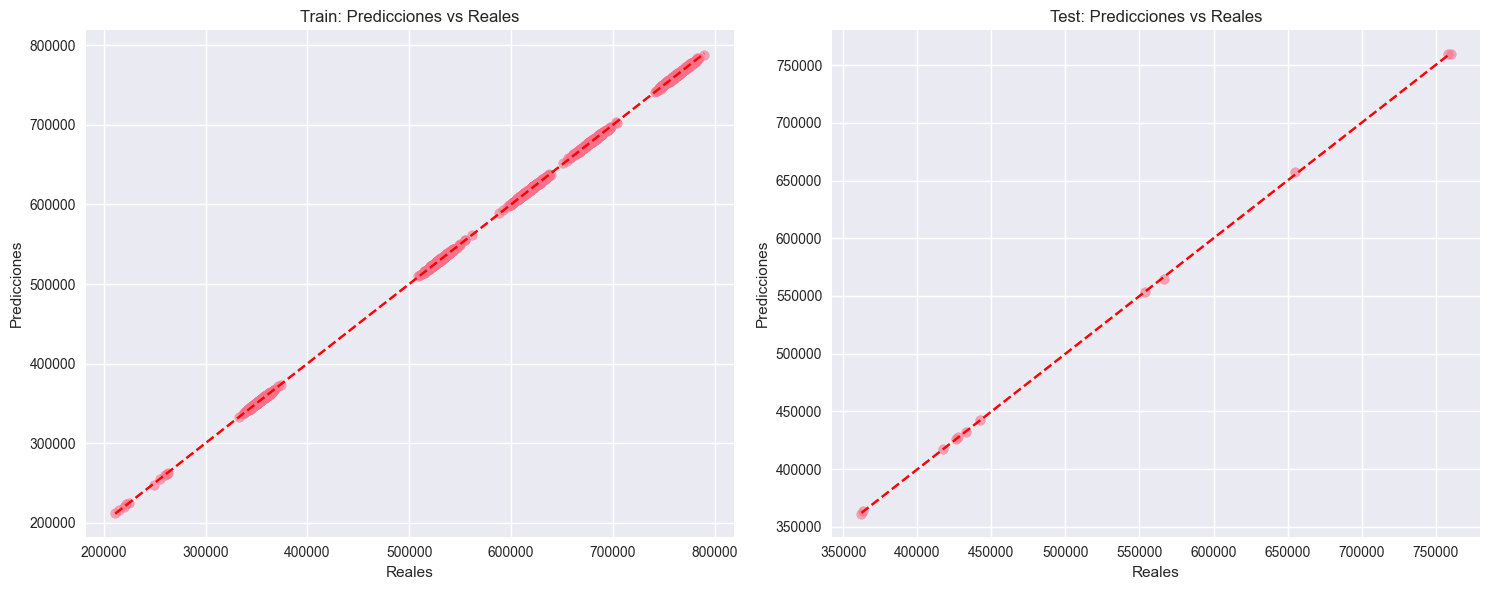

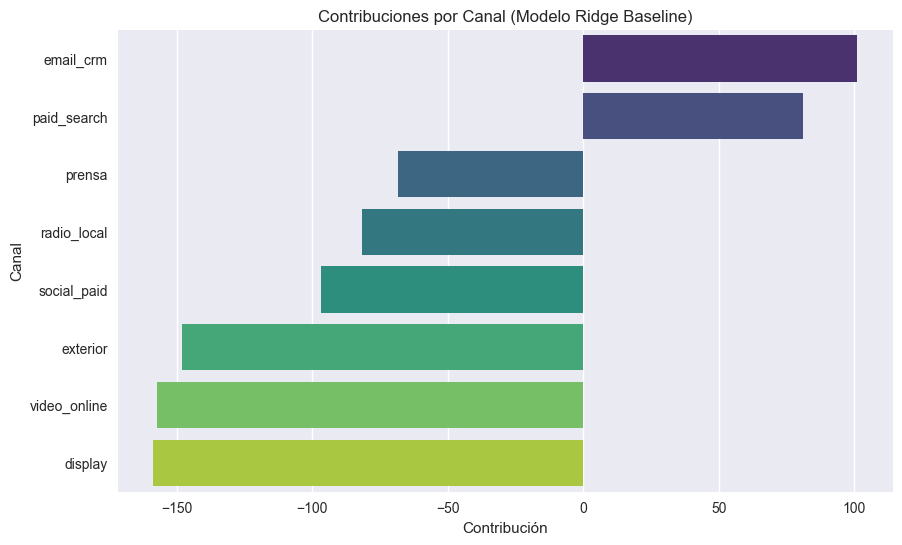

In [8]:
# 8. Visualizaciones
# Predicciones vs reales
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Train
axes[0].scatter(y_train, y_pred_train, alpha=0.6)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_title('Train: Predicciones vs Reales')
axes[0].set_xlabel('Reales')
axes[0].set_ylabel('Predicciones')

# Test
axes[1].scatter(y_test, y_pred_test, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Test: Predicciones vs Reales')
axes[1].set_xlabel('Reales')
axes[1].set_ylabel('Predicciones')

plt.tight_layout()
plt.savefig(FIGS_PATH + 'ridge_baseline_predicciones.png', dpi=300, bbox_inches='tight')
plt.show()

# Contribuciones por canal
plt.figure(figsize=(10, 6))
sns.barplot(data=contrib_df, x='contribución', y='canal', palette='viridis')
plt.title('Contribuciones por Canal (Modelo Ridge Baseline)')
plt.xlabel('Contribución')
plt.ylabel('Canal')
plt.savefig(FIGS_PATH + 'ridge_baseline_contribuciones.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# 9. Guardado del modelo
# Guardar modelo, scaler y metadata
model_data = {
    'model': ridge_model,
    'scaler': scaler,
    'features': features,
    'target': target,
    'best_alpha': best_alpha,
    'mape_train': mape_train,
    'mape_test': mape_test,
    'coef_df': coef_df,
    'contrib_df': contrib_df
}

joblib.dump(model_data, MODEL_PATH)
print(f"Modelo guardado en: {MODEL_PATH}")

Modelo guardado en: ../models/mmm_ridge_baseline.pkl


## 10. Conclusiones

### Resultados del modelo baseline

- **MAPE Train:** [Insertar valor]
- **MAPE Test:** [Insertar valor]
- **Coeficientes principales:** [Top 3 positivos y negativos]
- **Contribuciones por canal:** [Resumen]

### Decisiones tomadas

1. **Variable objetivo:** Usamos `ventas` (no log-transform). Evaluar residuos para heteroscedasticidad.
2. **Regularización:** Alpha óptimo = [Insertar]
3. **Features:** [Número] features escaladas
4. **Partición:** Train/test temporal ([n_train]/[test_weeks] semanas)
